# Flood Segmentation from Sentinel Satellite Imagery
### DATAX504 Practical Machine Learning — final project · Rishav Pandey (1716081)

**Goal:** given a satellite image chip, predict *for every pixel* whether it is flood water.
We train Keras U-Nets on the open **Sen1Floods11** dataset (Sentinel-1 radar + Sentinel-2 optical, hand-labelled water masks),
compare them against classical baselines, and finally run the trained radar model on a **Nepal** monsoon flood scene.

| What | Choice |
|---|---|
| Task | Binary semantic segmentation (water / not water) |
| Data | Sen1Floods11 hand-labelled split: 446 chips of 512×512 px, 11 flood events |
| Model | U-Net (encoder–decoder ConvNet with skip connections), Keras functional API |
| Primary metric | **Water-class IoU on the Bolivia hold-out** (an unseen flood event). Plain accuracy is reported only to show why it misleads |
| Baselines | "Everything is dry", Otsu threshold on radar VH, NDWI threshold on optical, per-pixel dense network |
| Experiments | Input bands (S1 / S2 / both), loss function, regularisation, normalisation, 3 random seeds |
| Generalisation | Held-out Bolivia event + unlabelled Nepal case study |

**How to run**
1. Open this notebook in Google Colab → *Runtime → Change runtime type → GPU (T4)*.
2. Run cells top to bottom. The data is downloaded once to your Google Drive (Section 3).
3. Training (Section 13) is checkpointed to Drive. If Colab disconnects, reconnect and **re-run all cells** — training resumes from the last finished epoch, and finished experiments are skipped.

Callouts marked **DLwP** link each step to the concept it demonstrates from *Deep Learning with Python* (Chollet).

## Concept map

| Deep-learning concept (DLwP) | Where it happens |
|---|---|
| Tensors, shapes, channels-last images | §4, §6 |
| Train / validation / test split, information leakage | §5 |
| Feature normalisation using training statistics only | §5 |
| Data pipelines with `tf.data`, batching, prefetching | §6 |
| Data augmentation (random crops, flips, rotations) | §6 |
| Beat a common-sense baseline first | §7 |
| ConvNets, max-pooling, transposed convolution | §8 |
| U-Net: encoder–decoder with skip connections | §8 |
| Batch normalisation, dropout (regularisation) | §8 |
| Keras functional API | §8 |
| Custom loss (masked BCE + Dice) for class imbalance | §9 |
| Custom stateful metric by subclassing `keras.metrics.Metric` | §9 |
| Callbacks: checkpointing, early stopping, LR scheduling, logging, fault tolerance | §10 |
| Overfit a single batch as a sanity check | §11 |
| Over- vs under-fitting, reading learning curves | §14 |
| Choosing a decision threshold on validation data, not test | §15 |
| Evaluating generalisation on out-of-distribution data | §15, §16 |
| Mixed-precision training | §1 |

## 1. Setup

In [1]:
import os, sys, json, math, random, re, time, subprocess
import urllib.request, urllib.parse
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

IN_COLAB = "google.colab" in sys.modules
# Smoke-test mode runs the whole notebook on tiny synthetic data in a few minutes on a CPU.
# Leave it off for the real project.
SMOKE_TEST = os.environ.get("FLOOD_SMOKE_TEST", "0") == "1"

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rasterio", "scikit-image"], check=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_origin
from skimage.filters import threshold_otsu
from tqdm.auto import tqdm

import tensorflow as tf
import keras
from keras import layers, ops

SEED = 42
keras.utils.set_random_seed(SEED)  # seeds Python, NumPy and TensorFlow

GPUS = tf.config.list_physical_devices("GPU")
if GPUS:
    # DLwP: mixed precision — float16 maths on the GPU roughly doubles speed;
    # the final layer stays float32 for numerical stability.
    keras.mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow", tf.__version__, "| Keras", keras.__version__)
print("GPU:", GPUS if GPUS else "none (CPU only — fine for the smoke test, too slow for real training)")
print("Smoke test:", SMOKE_TEST)

TensorFlow 2.21.0 | Keras 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Smoke test: False


In [3]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/nepal-flood-segmentation")
    LOCAL_DIR = Path("/content")          # fast local disk for the training cache
else:
    PROJECT_DIR = Path.cwd()
    LOCAL_DIR = PROJECT_DIR

if SMOKE_TEST:
    DATA_DIR = PROJECT_DIR / "smoke" / "data"
    CACHE_DIR = PROJECT_DIR / "smoke" / "cache"
    RUNS_DIR = PROJECT_DIR / "smoke" / "runs"
    NEPAL_DIR = PROJECT_DIR / "smoke" / "nepal"
else:
    DATA_DIR = LOCAL_DIR / "data" / "sen1floods11"
    CACHE_DIR = LOCAL_DIR / "cache"
    RUNS_DIR = PROJECT_DIR / "runs"
    NEPAL_DIR = PROJECT_DIR / "nepal"

for d in (DATA_DIR, CACHE_DIR, RUNS_DIR, NEPAL_DIR):
    d.mkdir(parents=True, exist_ok=True)

CFG = dict(
    chip_size=512,      # Sen1Floods11 chips are 512x512
    crop_size=256,      # random training crops (augmentation + fits GPU memory)
    batch_size=16,
    epochs=300,         # upper bound; early stopping decides the real number
    patience=15,        # epochs without val IoU improvement before stopping
    lr=1e-3,
    base_filters=32,
    depth=4,
    dropout=0.3,
    steps_per_epoch=None,  # None = 2 passes worth of random crops per epoch
)
if SMOKE_TEST:
    CFG.update(batch_size=2, epochs=2, patience=2, base_filters=8, steps_per_epoch=2)

S1_BANDS = ["VV", "VH"]
S2_BANDS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B10", "B11", "B12"]
ALL_BANDS = S1_BANDS + S2_BANDS
band_idx = lambda names: [ALL_BANDS.index(b) for b in names]

print("Project dir:", PROJECT_DIR)
print(json.dumps(CFG, indent=1))

Mounted at /content/drive
Project dir: /content/drive/MyDrive/nepal-flood-segmentation
{
 "chip_size": 512,
 "crop_size": 256,
 "batch_size": 16,
 "epochs": 300,
 "patience": 15,
 "lr": 0.001,
 "base_filters": 32,
 "depth": 4,
 "dropout": 0.3,
 "steps_per_epoch": null
}


## 2. The dataset: Sen1Floods11

Bonafilia et al., *Sen1Floods11: a georeferenced dataset to train and test deep learning flood algorithms for Sentinel-1*, CVPR Workshops 2020.

* **Sentinel-1 (S1)** — radar, bands **VV** and **VH** in decibels. Radar sees through clouds, which matters because floods happen under monsoon clouds. Calm water reflects the radar pulse away from the satellite, so water looks **dark**.
* **Sentinel-2 (S2)** — optical, 13 spectral bands (B1…B12). Very informative on clear days, useless under cloud.
* **Labels** — `1` = water, `0` = not water, `-1` = no data / not labelled. The `-1` pixels must be **ignored** by the loss and metrics.
* We use the 446 **hand-labelled** chips with the official train / validation / test splits, plus the **Bolivia** event that the authors hold out entirely to test generalisation to an unseen place.

## 3. Download

Files are fetched over HTTPS from the public Google Cloud bucket `gs://sen1floods11` (no account needed) and stored on Drive,
so this runs **once**. Re-running skips files that are already complete. Expect several GB and 20–60 minutes.

In [4]:
BUCKET = "sen1floods11"
PREFIXES = {
    "S1Hand": "v1.1/data/flood_events/HandLabeled/S1Hand/",
    "S2Hand": "v1.1/data/flood_events/HandLabeled/S2Hand/",
    "LabelHand": "v1.1/data/flood_events/HandLabeled/LabelHand/",
    "splits": "v1.1/splits/flood_handlabeled/",
}


def gcs_list(prefix):
    items, token = [], None
    while True:
        q = {"prefix": prefix, "fields": "items(name,size),nextPageToken"}
        if token:
            q["pageToken"] = token
        url = f"https://storage.googleapis.com/storage/v1/b/{BUCKET}/o?" + urllib.parse.urlencode(q)
        with urllib.request.urlopen(url, timeout=60) as r:
            page = json.load(r)
        items += page.get("items", [])
        token = page.get("nextPageToken")
        if not token:
            return [i for i in items if not i["name"].endswith("/")]


def gcs_download(item, out_dir):
    dest = out_dir / Path(item["name"]).name
    if dest.exists() and dest.stat().st_size == int(item["size"]):
        return "skipped"
    url = f"https://storage.googleapis.com/{BUCKET}/" + urllib.parse.quote(item["name"])
    tmp = dest.with_name(dest.name + ".part")
    for attempt in range(4):
        try:
            urllib.request.urlretrieve(url, tmp)
            tmp.replace(dest)
            return "downloaded"
        except Exception as e:
            err = e
            time.sleep(2 ** attempt)
    raise err


def download_sen1floods11(data_dir):
    for sub, prefix in PREFIXES.items():
        items = gcs_list(prefix)
        if not items:
            raise RuntimeError(f"Nothing found under gs://{BUCKET}/{prefix} — the bucket layout may have changed. "
                               "Browse https://console.cloud.google.com/storage/browser/sen1floods11 and update PREFIXES.")
        out = data_dir / sub
        out.mkdir(parents=True, exist_ok=True)
        gb = sum(int(i["size"]) for i in items) / 1e9
        print(f"{sub}: {len(items)} files, {gb:.2f} GB")
        with ThreadPoolExecutor(16) as ex:
            list(tqdm(ex.map(lambda it: gcs_download(it, out), items), total=len(items), desc=sub))


def make_synthetic_dataset(data_dir, n=12, size=512, seed=0):
    # Fake chips with the same file layout as Sen1Floods11, for the smoke test only.
    from scipy.ndimage import gaussian_filter
    rng = np.random.default_rng(seed)
    for sub in ("S1Hand", "S2Hand", "LabelHand", "splits"):
        (data_dir / sub).mkdir(parents=True, exist_ok=True)
    land = np.array([1200, 1000, 900, 800, 1100, 1800, 2100, 2300, 2400, 600, 20, 1700, 1000])
    water = np.array([1000, 900, 800, 500, 400, 300, 250, 200, 180, 100, 10, 80, 50])
    prof = dict(driver="GTiff", width=size, height=size, crs="EPSG:4326",
                transform=from_origin(85.0, 28.0, 1e-4, 1e-4))
    ids = []
    for i in range(n):
        cid = f"Synth_{i:04d}"
        ids.append(cid)
        field = gaussian_filter(rng.standard_normal((size, size)), 12)
        w = field > np.quantile(field, 0.8)
        nz = lambda s: rng.normal(0, s, (size, size))
        s1 = np.stack([-9 + nz(2) - 11 * w, -16 + nz(2) - 9 * w]).astype("float32")
        s2 = np.stack([np.where(w, water[b], land[b]) + nz(80) for b in range(13)]).astype("float32")
        lab = w.astype("int16")[None]
        lab[:, :8, :] = -1
        for sub, arr in (("S1Hand", s1), ("S2Hand", s2), ("LabelHand", lab)):
            with rasterio.open(data_dir / sub / f"{cid}_{sub}.tif", "w", count=arr.shape[0], dtype=arr.dtype, **prof) as dst:
                dst.write(arr)
    groups = {"train": ids[:6], "valid": ids[6:8], "test": ids[8:10], "bolivia": ids[10:]}
    for name, g in groups.items():
        pd.DataFrame([[f"{c}_S1Hand.tif", f"{c}_LabelHand.tif"] for c in g]).to_csv(
            data_dir / "splits" / f"flood_{name}_data.csv", header=False, index=False)


if SMOKE_TEST:
    make_synthetic_dataset(DATA_DIR)
else:
    download_sen1floods11(DATA_DIR)

for sub in PREFIXES:
    print(sub, len(list((DATA_DIR / sub).glob("*"))), "files")

S1Hand: 446 files, 0.73 GB


S1Hand:   0%|          | 0/446 [00:00<?, ?it/s]

S2Hand: 446 files, 1.02 GB


S2Hand:   0%|          | 0/446 [00:00<?, ?it/s]

LabelHand: 446 files, 0.00 GB


LabelHand:   0%|          | 0/446 [00:00<?, ?it/s]

splits: 4 files, 0.00 GB


splits:   0%|          | 0/4 [00:00<?, ?it/s]

S1Hand 446 files
S2Hand 446 files
LabelHand 446 files
splits 4 files


## 4. Explore the data

In [5]:
def chip_id(name):
    m = re.match(r"^(.+?)_(S1Hand|S2Hand|LabelHand)", Path(str(name)).name)
    return m.group(1) if m else None


def read_chip(cid, data_dir=DATA_DIR):
    with rasterio.open(data_dir / "S1Hand" / f"{cid}_S1Hand.tif") as src:
        s1 = src.read().astype("float32")
    with rasterio.open(data_dir / "S2Hand" / f"{cid}_S2Hand.tif") as src:
        s2 = src.read().astype("float32")
    with rasterio.open(data_dir / "LabelHand" / f"{cid}_LabelHand.tif") as src:
        lab = src.read(1).astype("int8")
    x = np.concatenate([s1, s2], axis=0).transpose(1, 2, 0)  # bands-first → channels-last (H, W, C)
    return x, lab


def rgb(x_phys):
    # True-colour image from S2 B4/B3/B2 (physical reflectance 0..1), contrast-stretched.
    img = x_phys[..., band_idx(["B4", "B3", "B2"])]
    lo, hi = np.nanpercentile(img, 2), np.nanpercentile(img, 98)
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)


all_ids = sorted({chip_id(p.name) for p in (DATA_DIR / "S1Hand").glob("*.tif")} - {None})
print(len(all_ids), "chips, e.g.", all_ids[:3])
events = pd.Series([c.split("_")[0] for c in all_ids]).value_counts()
print("\nChips per flood event:\n", events.to_string())

x0, y0 = read_chip(all_ids[0])
# DLwP: every image is a rank-3 tensor (height, width, channels).
print("\nOne chip:", x0.shape, x0.dtype, "| label:", y0.shape, "values", np.unique(y0))

446 chips, e.g. ['Bolivia_103757', 'Bolivia_129334', 'Bolivia_195474']

Chips per flood event:
 USA          69
India        68
Paraguay     67
Ghana        53
Sri-Lanka    42
Spain        30
Mekong       30
Pakistan     28
Somalia      26
Nigeria      18
Bolivia      15

One chip: (512, 512, 15) float32 | label: (512, 512) values [-1  0  1]


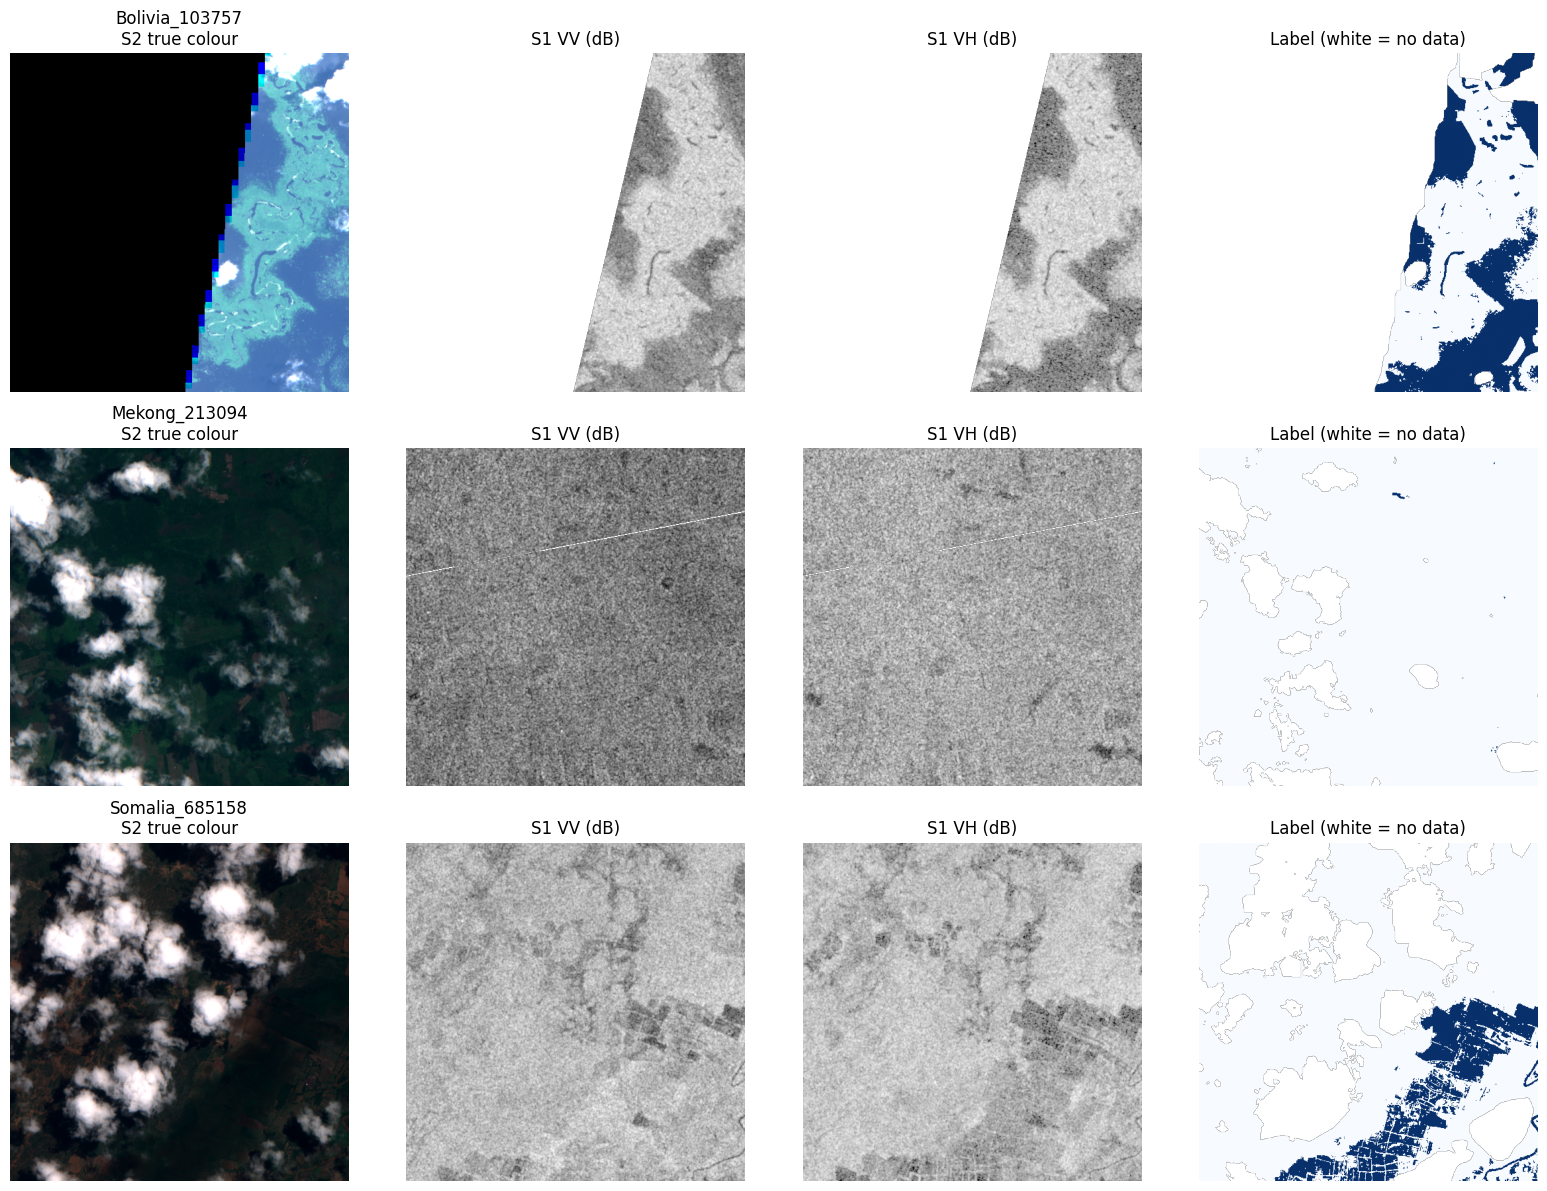

In [6]:
def to_physical(x):
    # Clip outliers into physical ranges: radar in dB, optical as 0..1 reflectance.
    x = x.copy()
    x[..., :2] = np.clip(x[..., :2], -50, 5)
    x[..., 2:] = np.clip(x[..., 2:] / 10000.0, 0, 1)
    return x


fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for row, cid in zip(axes, all_ids[:: max(1, len(all_ids) // 3)][:3]):
    x, y = read_chip(cid)
    xp = to_physical(x)
    row[0].imshow(rgb(xp)); row[0].set_title(f"{cid}\nS2 true colour")
    row[1].imshow(xp[..., 0], cmap="gray"); row[1].set_title("S1 VV (dB)")
    row[2].imshow(xp[..., 1], cmap="gray"); row[2].set_title("S1 VH (dB)")
    row[3].imshow(np.ma.masked_where(y < 0, y), cmap="Blues", vmin=0, vmax=1); row[3].set_title("Label (white = no data)")
    for a in row:
        a.axis("off")
plt.tight_layout(); plt.show()

In [7]:
# Class balance — the reason we cannot judge the model by accuracy.
water = dry = nodata = 0
for cid in tqdm(all_ids, desc="counting"):
    _, y = read_chip(cid)
    water += (y == 1).sum(); dry += (y == 0).sum(); nodata += (y == -1).sum()
labelled = water + dry
print(f"water   {water / labelled:6.1%} of labelled pixels")
print(f"dry     {dry / labelled:6.1%} of labelled pixels")
print(f"no-data {nodata / (labelled + nodata):6.1%} of all pixels (ignored)")
print(f"\nA model that always answers 'dry' scores {dry / labelled:.1%} accuracy and is useless.")

counting:   0%|          | 0/446 [00:00<?, ?it/s]

water    10.6% of labelled pixels
dry      89.4% of labelled pixels
no-data  13.6% of all pixels (ignored)

A model that always answers 'dry' scores 89.4% accuracy and is useless.


> **DLwP — choosing the right measure of success.** Water is a small minority of pixels, so accuracy rewards a model that predicts "dry" everywhere.
> We rank models by **IoU of the water class** = TP / (TP + FP + FN), which ignores the easy true negatives, and also report F1, precision and recall.

## 5. Splits and normalisation

In [8]:
def load_splits(data_dir=DATA_DIR):
    keys = {"train": "train", "val": "valid", "test": "test", "bolivia": "bolivia"}
    available = set(all_ids)
    splits = {}
    for key, kw in keys.items():
        files = [p for p in (data_dir / "splits").glob("*.csv") if kw in p.name.lower()]
        if files:
            df = pd.read_csv(files[0], header=None)
            ids = {chip_id(v) for v in df.iloc[:, 0]} - {None}
            splits[key] = sorted(ids & available)
    if not splits.get("train"):
        print("WARNING: Official split files not found — falling back to a seeded random 60/20/20 split.")
        ids = sorted(available)
        random.Random(SEED).shuffle(ids)
        n = len(ids)
        splits = {"train": ids[: int(.6 * n)], "val": ids[int(.6 * n): int(.8 * n)], "test": ids[int(.8 * n):]}
    return splits


SPLITS = load_splits()
for k, v in SPLITS.items():
    print(f"{k:8s} {len(v):4d} chips")
overlap = set(SPLITS["train"]) & (set(SPLITS["val"]) | set(SPLITS["test"]))
assert not overlap, f"train/eval overlap: {overlap}"

train     252 chips
val        89 chips
test       90 chips
bolivia    15 chips


> **DLwP — information leakage.** The validation set is used to make decisions (early stopping, the decision threshold), so it gradually leaks into the model.
> The **test** set is touched exactly once, at the end. Normalisation statistics are computed on the **training set only**; computing them on all data would leak test information into training.

In [9]:
stats_path = RUNS_DIR / "norm_stats.json"
if stats_path.exists():
    stats = json.loads(stats_path.read_text())
else:
    s = np.zeros(len(ALL_BANDS)); s2 = np.zeros(len(ALL_BANDS)); n = np.zeros(len(ALL_BANDS))
    for cid in tqdm(SPLITS["train"], desc="train stats"):
        x = to_physical(read_chip(cid)[0]).reshape(-1, len(ALL_BANDS)).astype("float64")
        ok = np.isfinite(x)
        s += np.where(ok, x, 0).sum(0); s2 += np.where(ok, x * x, 0).sum(0); n += ok.sum(0)
    mean = s / n
    stats = {"mean": mean.tolist(), "std": np.sqrt(s2 / n - mean ** 2).tolist(), "bands": ALL_BANDS}
    stats_path.write_text(json.dumps(stats, indent=1))

MEAN = np.array(stats["mean"], dtype="float32")
STD = np.array(stats["std"], dtype="float32")
print(pd.DataFrame({"mean": MEAN, "std": STD}, index=ALL_BANDS).round(3).T.to_string())


def normalise(x_phys, bands=slice(None)):
    # DLwP: feature-wise standardisation → zero mean, unit variance per band.
    x = (x_phys - MEAN[bands]) / STD[bands]
    return np.nan_to_num(x, nan=0.0)  # missing radar pixels become the band mean

          VV         VH     B1     B2     B3     B4     B5     B6     B7     B8    B8A     B9    B10    B11    B12
mean -10.394 -17.240999  0.163  0.140  0.136  0.122  0.147  0.239  0.285  0.262  0.308  0.049  0.006  0.203  0.118
std    4.033   4.753000  0.070  0.074  0.074  0.086  0.078  0.092  0.108  0.102  0.120  0.034  0.014  0.098  0.076


## 6. Input pipeline and augmentation

Reading GeoTIFFs every step would starve the GPU, so each split is preprocessed once into a NumPy array on local disk
(float16, memory-mapped), then streamed with `tf.data`.

In [10]:
def build_cache(split):
    ids = SPLITS[split]
    xp, yp, meta = CACHE_DIR / f"{split}_x.npy", CACHE_DIR / f"{split}_y.npy", CACHE_DIR / f"{split}_ids.json"
    if xp.exists() and yp.exists() and meta.exists() and json.loads(meta.read_text()) == ids:
        return
    H = W = CFG["chip_size"]
    X = np.lib.format.open_memmap(xp, mode="w+", dtype=np.float16, shape=(len(ids), H, W, len(ALL_BANDS)))
    Y = np.lib.format.open_memmap(yp, mode="w+", dtype=np.int8, shape=(len(ids), H, W))
    for i, cid in enumerate(tqdm(ids, desc=f"caching {split}")):
        x, y = read_chip(cid)
        assert x.shape[:2] == (H, W), (cid, x.shape)
        X[i] = normalise(to_physical(x)).astype(np.float16)
        Y[i] = y
    X.flush(); Y.flush(); del X, Y
    meta.write_text(json.dumps(ids))


def load_cache(split):
    return (np.load(CACHE_DIR / f"{split}_x.npy", mmap_mode="r"),
            np.load(CACHE_DIR / f"{split}_y.npy", mmap_mode="r"))


for split in SPLITS:
    build_cache(split)

caching train:   0%|          | 0/252 [00:00<?, ?it/s]

caching val:   0%|          | 0/89 [00:00<?, ?it/s]

caching test:   0%|          | 0/90 [00:00<?, ?it/s]

caching bolivia:   0%|          | 0/15 [00:00<?, ?it/s]

batch x: (4, 256, 256, 15) <dtype: 'float32'> | batch y: (4, 256, 256, 1) values [-1.  0.  1.]


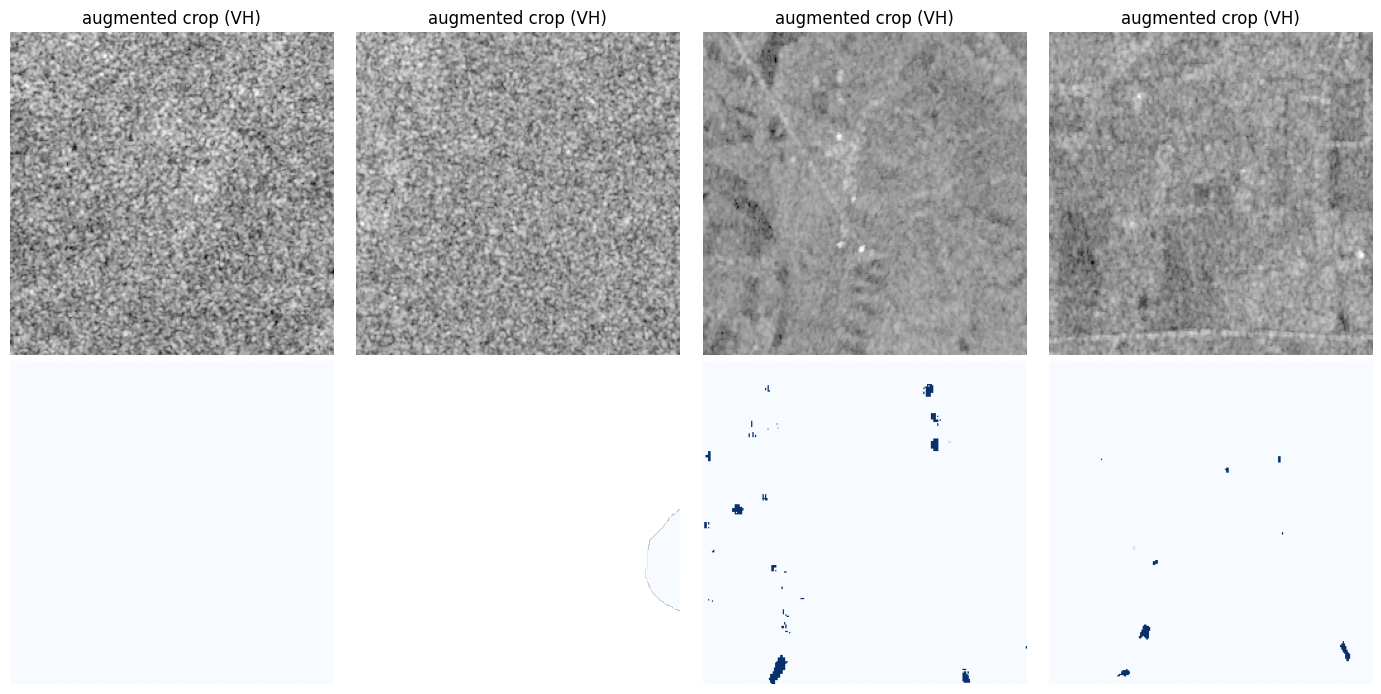

In [11]:
def per_chip_standardise(x):
    # Alternative normalisation for the comparison: each image is standardised by its own statistics
    # instead of the training-set statistics.
    return (x - x.mean(axis=(0, 1))) / (x.std(axis=(0, 1)) + 1e-3)


def train_dataset(bands, crop=CFG["crop_size"], batch=CFG["batch_size"], seed=SEED, augment=True, norm="global"):
    # Infinite stream of random (optionally augmented) crops.
    X, Y = load_cache("train")
    n, H, W, _ = X.shape
    idx = band_idx(bands)
    rng = np.random.default_rng(seed)

    def gen():
        while True:
            for _ in range(10):  # avoid crops that contain no labelled pixels
                i, r, c = rng.integers(n), rng.integers(0, H - crop + 1), rng.integers(0, W - crop + 1)
                y = np.asarray(Y[i, r:r + crop, c:c + crop], dtype=np.float32)
                if (y >= 0).any():
                    break
            x = np.asarray(X[i, r:r + crop, c:c + crop], dtype=np.float32)[..., idx]
            # DLwP: data augmentation — the same random rotation/flip is applied to image and mask.
            if augment:
                k = rng.integers(4)
                x, y = np.rot90(x, k), np.rot90(y, k)
                if rng.random() < 0.5:
                    x, y = x[:, ::-1], y[:, ::-1]
            if norm == "per_chip":
                x = per_chip_standardise(x)
            yield np.ascontiguousarray(x), np.ascontiguousarray(y)[..., None]

    sig = (tf.TensorSpec((crop, crop, len(idx)), tf.float32), tf.TensorSpec((crop, crop, 1), tf.float32))
    return tf.data.Dataset.from_generator(gen, output_signature=sig).batch(batch).prefetch(tf.data.AUTOTUNE)


def eval_dataset(split, bands, batch=4, norm="global"):
    # Full 512x512 chips in fixed order, no augmentation.
    X, Y = load_cache(split)
    idx = band_idx(bands)

    def gen():
        for i in range(X.shape[0]):
            x = np.asarray(X[i], dtype=np.float32)[..., idx]
            if norm == "per_chip":
                x = per_chip_standardise(x)
            yield x, np.asarray(Y[i], dtype=np.float32)[..., None]

    H = W = CFG["chip_size"]
    sig = (tf.TensorSpec((H, W, len(idx)), tf.float32), tf.TensorSpec((H, W, 1), tf.float32))
    return tf.data.Dataset.from_generator(gen, output_signature=sig).batch(batch).prefetch(tf.data.AUTOTUNE)


xb, yb = next(iter(train_dataset(ALL_BANDS, batch=4)))
print("batch x:", xb.shape, xb.dtype, "| batch y:", yb.shape, "values", np.unique(yb.numpy()))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j in range(4):
    axes[0, j].imshow(xb[j, ..., 1], cmap="gray"); axes[0, j].set_title("augmented crop (VH)")
    axes[1, j].imshow(np.ma.masked_where(yb[j, ..., 0] < 0, yb[j, ..., 0]), cmap="Blues", vmin=0, vmax=1)
    axes[0, j].axis("off"); axes[1, j].axis("off")
plt.tight_layout(); plt.show()

## 7. Baselines — what a deep model has to beat

> **DLwP — beat a common-sense baseline.** Before training anything, measure simple non-learned methods. A deep model is only worth its cost if it clearly beats them.

1. **All dry** — predict "not water" everywhere. High accuracy, zero IoU.
2. **Otsu on VH** — the classic radar method: per chip, find the threshold that best separates dark (water) from bright pixels.
3. **NDWI > 0** — the classic optical water index, (Green − NIR) / (Green + NIR).

In [12]:
def confusion(y_true, pred):
    valid = y_true >= 0
    t, f = (y_true == 1) & valid, (y_true == 0) & valid
    return np.array([(t & pred).sum(), (f & pred).sum(), (t & ~pred).sum(), (f & ~pred).sum()], dtype=np.int64)


def scores(cm):
    tp, fp, fn, tn = cm.astype("float64")
    e = 1e-9
    return {"water_iou": tp / (tp + fp + fn + e), "f1": 2 * tp / (2 * tp + fp + fn + e),
            "precision": tp / (tp + fp + e), "recall": tp / (tp + fn + e),
            "accuracy": (tp + tn) / (tp + fp + fn + tn + e)}


def baseline_predictions(split):
    X, Y = load_cache(split)
    vh, g, nir = band_idx(["VH"])[0], band_idx(["B3"])[0], band_idx(["B8"])[0]
    out = {"All dry": [], "Otsu (S1 VH)": [], "NDWI > 0 (S2)": []}
    for i in range(X.shape[0]):
        x, y = np.asarray(X[i], dtype=np.float32), np.asarray(Y[i])
        out["All dry"].append(np.zeros_like(y, dtype=bool))
        # Otsu is unaffected by standardisation (a monotonic rescale), so normalised VH works directly.
        v = x[..., vh]
        try:
            t = threshold_otsu(v[y >= 0]) if (y >= 0).any() else threshold_otsu(v)
        except ValueError:
            t = v.min()
        out["Otsu (S1 VH)"].append(v < t)
        # NDWI needs physical reflectance, so undo the standardisation.
        G, N = x[..., g] * STD[g] + MEAN[g], x[..., nir] * STD[nir] + MEAN[nir]
        out["NDWI > 0 (S2)"].append((G - N) / (G + N + 1e-6) > 0)
    return {k: np.stack(v) for k, v in out.items()}


RESULTS = []
for split in ("val", "test", "bolivia"):
    if split not in SPLITS:
        continue
    Y = np.asarray(load_cache(split)[1])
    for name, pred in baseline_predictions(split).items():
        RESULTS.append({"method": name, "split": split, **scores(confusion(Y, pred))})

pd.DataFrame(RESULTS).query("split == 'test'").set_index("method").round(3)

,split,water_iou,f1,precision,recall,accuracy
method,,,,,,
All dry,test,0.000,0.000,0.000,0.000,0.875
Otsu (S1 VH),test,0.229,0.373,0.252,0.714,0.699
NDWI > 0 (S2),test,0.758,0.862,0.922,0.810,0.968


## 8. The model: U-Net

> **DLwP — ConvNets for segmentation.** The **encoder** (convolutions + max-pooling) shrinks the image while learning *what* is in it.
> The **decoder** (transposed convolutions) grows it back to full resolution to say *where*. **Skip connections** copy fine detail from each encoder level to the matching decoder level, so river edges stay sharp.
> **Batch normalisation** stabilises training and **spatial dropout** in the bottleneck fights overfitting. Built with the **functional API**, because skip connections make the graph non-sequential.

In [13]:
def conv_block(x, filters, name):
    for i in range(2):
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_initializer="he_normal", name=f"{name}_conv{i}")(x)
        x = layers.BatchNormalization(name=f"{name}_bn{i}")(x)
        x = layers.Activation("relu", name=f"{name}_relu{i}")(x)
    return x


def build_unet(n_channels, base=CFG["base_filters"], depth=CFG["depth"], dropout=CFG["dropout"], name="unet"):
    # Spatial size is None: the network is fully convolutional, so it trains on 256px crops
    # and predicts on 512px chips or whole scenes (any size divisible by 2**depth).
    inputs = keras.Input((None, None, n_channels), name="image")
    x, skips = inputs, []
    for d in range(depth):
        x = conv_block(x, base * 2 ** d, f"enc{d}")
        skips.append(x)
        x = layers.MaxPooling2D(name=f"pool{d}")(x)
    x = conv_block(x, base * 2 ** depth, "bottleneck")
    x = layers.SpatialDropout2D(dropout, name="dropout")(x)
    for d in reversed(range(depth)):
        x = layers.Conv2DTranspose(base * 2 ** d, 2, strides=2, padding="same", name=f"up{d}")(x)
        x = layers.Concatenate(name=f"skip{d}")([x, skips[d]])
        x = conv_block(x, base * 2 ** d, f"dec{d}")
    outputs = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32", name="water_prob")(x)
    return keras.Model(inputs, outputs, name=name)


def build_pixel_mlp(n_channels, hidden=(64, 64), dropout=0.3, name="pixel_mlp"):
    # Per-pixel dense network: 1x1 convolutions are Dense layers applied to each pixel independently,
    # so this model sees a pixel's band values but no spatial context. It isolates what the U-Net's
    # spatial context adds.
    inputs = keras.Input((None, None, n_channels), name="image")
    x = inputs
    for i, h in enumerate(hidden):
        x = layers.Conv2D(h, 1, activation="relu", name=f"dense{i}")(x)
        x = layers.Dropout(dropout, name=f"dropout{i}")(x)
    outputs = layers.Conv2D(1, 1, activation="sigmoid", dtype="float32", name="water_prob")(x)
    return keras.Model(inputs, outputs, name=name)


demo = build_unet(len(ALL_BANDS))
demo.summary(line_length=110)
print(f"{demo.count_params():,} parameters")

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape              ┃          Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)             │ (None, None, None, 15)    │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc0_conv0 (Conv2D)            │ (None, None, None, 32)    │            4,320 │ image[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc0_bn0 (BatchNormalization)  │ (None, None, None, 32)    │              128 │ enc0_conv0[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc0_relu0 (Activation)        │ (None, None, None, 32)    │                0 │ enc0_bn0[0][0]             │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc0_conv1 (Conv2D)            │ (None, None, None, 32)    │            9,216 │ enc0_relu0[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc0_bn1 (BatchNormalization)  │ (None, None, None, 32)    │              128 │ enc0_conv1[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc0_relu1 (Activation)        │ (None, None, None, 32)    │                0 │ enc0_bn1[0][0]             │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ pool0 (MaxPooling2D)           │ (None, None, None, 32)    │                0 │ enc0_relu1[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc1_conv0 (Conv2D)            │ (None, None, None, 64)    │           18,432 │ pool0[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc1_bn0 (BatchNormalization)  │ (None, None, None, 64)    │              256 │ enc1_conv0[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc1_relu0 (Activation)        │ (None, None, None, 64)    │                0 │ enc1_bn0[0][0]             │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc1_conv1 (Conv2D)            │ (None, None, None, 64)    │           36,864 │ enc1_relu0[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc1_bn1 (BatchNormalization)  │ (None, None, None, 64)    │              256 │ enc1_conv1[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc1_relu1 (Activation)        │ (None, None, None, 64)    │                0 │ enc1_bn1[0][0]             │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)           │ (None, None, None, 64)    │                0 │ enc1_relu1[0][0]           │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc2_conv0 (Conv2D)            │ (None, None, None, 128)   │           73,728 │ pool1[0][0]                │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ enc2_bn0 (BatchNormalization)  │ (None, None, None, 128)   │              512 │ enc2_conv0[0][0]           │
├───

 Total params: 7,772,385 (29.65 MB)

 Trainable params: 7,766,497 (29.63 MB)

 Non-trainable params: 5,888 (23.00 KB)

7,772,385 parameters


## 9. Loss and metrics for an imbalanced, partly-labelled problem

* **Masked loss** — pixels labelled `-1` get zero weight.
* **BCE + Dice** — binary cross-entropy gives stable per-pixel gradients; Dice loss directly optimises overlap with the water mask, so the rare class is not drowned out.
* **Custom metric** — a stateful Keras metric that accumulates TP/FP/FN/TN across all batches of an epoch, then reports IoU, F1 or accuracy (averaging per-batch IoU would be wrong).

In [14]:
EPS = 1e-6


def masked_bce_dice(y_true, y_pred):
    y_true = ops.cast(y_true, "float32")
    p = ops.clip(ops.cast(y_pred, "float32"), EPS, 1 - EPS)
    mask = ops.cast(y_true >= 0, "float32")
    y = ops.clip(y_true, 0.0, 1.0)
    bce = -(y * ops.log(p) + (1 - y) * ops.log(1 - p))
    bce = ops.sum(bce * mask) / (ops.sum(mask) + EPS)
    inter = ops.sum(p * y * mask)
    dice = 1 - (2 * inter + 1) / (ops.sum(p * mask) + ops.sum(y * mask) + 1)
    return bce + dice


class MaskedWaterMetric(keras.metrics.Metric):
    # DLwP: writing your own metric by subclassing keras.metrics.Metric.
    def __init__(self, kind="iou", threshold=0.5, name=None, **kwargs):
        super().__init__(name=name or f"water_{kind}", **kwargs)
        self.kind, self.threshold = kind, threshold
        self.tp, self.fp, self.fn, self.tn = (
            self.add_variable(shape=(), initializer="zeros", name=n) for n in ("tp", "fp", "fn", "tn"))

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true, y_pred = ops.cast(y_true, "float32"), ops.cast(y_pred, "float32")
        valid = y_true >= 0
        t = ops.logical_and(valid, y_true > 0.5)
        f = ops.logical_and(valid, y_true < 0.5)
        p = y_pred >= self.threshold
        count = lambda b: ops.sum(ops.cast(b, "float32"))
        self.tp.assign_add(count(ops.logical_and(t, p)))
        self.fp.assign_add(count(ops.logical_and(f, p)))
        self.fn.assign_add(count(ops.logical_and(t, ops.logical_not(p))))
        self.tn.assign_add(count(ops.logical_and(f, ops.logical_not(p))))

    def result(self):
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        if self.kind == "iou":
            return tp / (tp + fp + fn + EPS)
        if self.kind == "f1":
            return 2 * tp / (2 * tp + fp + fn + EPS)
        return (tp + tn) / (tp + fp + fn + tn + EPS)

    def reset_state(self):
        for v in (self.tp, self.fp, self.fn, self.tn):
            v.assign(0.0)


def masked_bce(y_true, y_pred):
    # Plain cross-entropy (no Dice term), for the loss-function comparison.
    y_true = ops.cast(y_true, "float32")
    p = ops.clip(ops.cast(y_pred, "float32"), EPS, 1 - EPS)
    mask = ops.cast(y_true >= 0, "float32")
    y = ops.clip(y_true, 0.0, 1.0)
    bce = -(y * ops.log(p) + (1 - y) * ops.log(1 - p))
    return ops.sum(bce * mask) / (ops.sum(mask) + EPS)


LOSSES = {"bce_dice": masked_bce_dice, "bce": masked_bce}


def compile_model(model, lr=CFG["lr"], loss="bce_dice"):
    model.compile(optimizer=keras.optimizers.Adam(lr), loss=LOSSES[loss],
                  metrics=[MaskedWaterMetric("iou"), MaskedWaterMetric("f1"), MaskedWaterMetric("accuracy")])
    return model


# Quick check on a hand-made example: 2 water pixels, 1 dry, 1 unlabelled.
yt = np.array([1, 1, 0, -1], "float32").reshape(1, 2, 2, 1)
yp = np.array([0.9, 0.2, 0.1, 0.9], "float32").reshape(1, 2, 2, 1)
m = MaskedWaterMetric("iou"); m.update_state(yt, yp)
print("IoU (expect 0.5):", float(m.result()), "| loss:", float(masked_bce_dice(yt, yp)))

IoU (expect 0.5): 0.4999997615814209 | loss: 0.8448145985603333


## 10. Training loop with callbacks

> **DLwP — callbacks.** Training for "100s of epochs" only makes sense with callbacks watching the validation set:
> * `ModelCheckpoint` keeps the weights of the best epoch by validation IoU.
> * `EarlyStopping` stops once validation IoU has not improved for `patience` epochs. More epochs past that point only memorise the training set (overfitting).
> * `ReduceLROnPlateau` halves the learning rate when validation loss stalls.
> * `BackupAndRestore` saves full training state every epoch, so a Colab disconnect costs at most one epoch.
> * `CSVLogger` keeps the learning curves on Drive.

In [15]:
def best_so_far(run_dir):
    log = run_dir / "history.csv"
    if log.exists():
        h = pd.read_csv(log)
        if "val_water_iou" in h and len(h):
            return float(h["val_water_iou"].max())
    return None


def run_experiment(name, spec, cfg=CFG):
    run_dir = RUNS_DIR / name
    run_dir.mkdir(parents=True, exist_ok=True)
    weights, done = run_dir / "best.weights.h5", run_dir / "done.json"
    bands = spec["bands"]
    keras.utils.set_random_seed(spec["seed"])  # different seeds → different initial weights and crop order
    if spec["model"] == "pixel_mlp":
        net = build_pixel_mlp(len(bands), dropout=spec["dropout"], name=name)
    else:
        net = build_unet(len(bands), cfg["base_filters"], cfg["depth"], spec["dropout"], name=name)
    model = compile_model(net, cfg["lr"], spec["loss"])

    if done.exists() and weights.exists():
        print(f"[{name}] already trained — loading best weights.")
        model.load_weights(weights)
        return model

    n_train = len(SPLITS["train"])
    steps = cfg["steps_per_epoch"] or max(1, 2 * n_train * (cfg["chip_size"] // cfg["crop_size"]) ** 2 // cfg["batch_size"])
    prev_best = best_so_far(run_dir)  # resuming: don't let a worse epoch overwrite the best checkpoint
    if prev_best is not None:
        print(f"[{name}] resuming, best val IoU so far {prev_best:.4f}")

    callbacks = [
        keras.callbacks.BackupAndRestore(str(run_dir / "backup")),
        keras.callbacks.ModelCheckpoint(str(weights), monitor="val_water_iou", mode="max", save_best_only=True,
                                        save_weights_only=True, initial_value_threshold=prev_best),
        keras.callbacks.EarlyStopping(monitor="val_water_iou", mode="max", patience=cfg["patience"]),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6),
        keras.callbacks.CSVLogger(str(run_dir / "history.csv"), append=True),
    ]
    t0 = time.time()
    train_ds = train_dataset(bands, cfg["crop_size"], cfg["batch_size"], seed=spec["seed"],
                             augment=spec["augment"], norm=spec["norm"])
    model.fit(train_ds, epochs=cfg["epochs"], steps_per_epoch=steps,
              validation_data=eval_dataset("val", bands, norm=spec["norm"]), callbacks=callbacks, verbose=2)
    if not weights.exists():
        model.save_weights(weights)
    model.load_weights(weights)
    done.write_text(json.dumps({"spec": spec, "minutes": round((time.time() - t0) / 60, 1),
                                "best_val_water_iou": best_so_far(run_dir), "cfg": cfg}, indent=1))
    return model

## 11. Sanity check: can the model overfit one batch?

> **DLwP — first get a model that can overfit.** If a network cannot memorise a single batch, something is broken (labels, loss, learning rate), and running 300 epochs would waste hours.

In [16]:
xb, yb = next(iter(train_dataset(ALL_BANDS, batch=4)))
probe = compile_model(build_unet(len(ALL_BANDS), base=16, name="overfit_probe"), lr=1e-3)
hist = probe.fit(xb, yb, epochs=5 if SMOKE_TEST else 150, verbose=0)
print(f"loss {hist.history['loss'][0]:.3f} → {hist.history['loss'][-1]:.3f}")
print(f"train IoU on the memorised batch: {hist.history['water_iou'][-1]:.3f} (should approach 1.0 on real data)")
del probe

loss 2.603 → 1.156
train IoU on the memorised batch: 0.511 (should approach 1.0 on real data)


## 12. Experiments

Each experiment changes **one** design choice relative to the reference model `unet_s1s2`, so any difference in IoU can be attributed to that choice.
They are listed in priority order. Training runs them top to bottom and skips anything already finished, so if time runs out the most important results already exist.
Rough cost on a free Colab T4: 1–2 hours per U-Net, a few minutes for the pixel MLP.

| Question from the proposal | Experiments |
|---|---|
| Which input bands? | `unet_s1`, `unet_s2`, `unet_s1s2` |
| Does spatial context matter? (per-pixel dense network) | `pixel_mlp_s1s2` vs `unet_s1s2` |
| Loss function | `unet_s1s2_bce` (no Dice term) vs `unet_s1s2` |
| Regularisation | `unet_s1s2_noreg` (no dropout, no augmentation) vs `unet_s1s2` |
| Normalisation | `unet_s1s2_perchip` (per-image standardisation) vs `unet_s1s2` (training-set statistics) |
| Seed-to-seed variance | `unet_s1s2`, `unet_s1s2_seed1`, `unet_s1s2_seed2` |

In [17]:
REFERENCE = dict(model="unet", loss="bce_dice", dropout=CFG["dropout"], augment=True, norm="global", seed=SEED)


def variant(bands, **changes):
    return {**REFERENCE, "bands": bands, **changes}


EXPERIMENTS = {
    # Priority 1 — input bands
    "unet_s1s2": variant(ALL_BANDS),                     # reference model: both sensors fused at the input
    "unet_s1": variant(S1_BANDS),                        # radar only — works through clouds, used for Nepal
    # Priority 2 — per-pixel dense network baseline
    "pixel_mlp_s1s2": variant(ALL_BANDS, model="pixel_mlp"),
    # Priority 3 — design-choice ablations
    "unet_s1s2_bce": variant(ALL_BANDS, loss="bce"),
    "unet_s1s2_noreg": variant(ALL_BANDS, dropout=0.0, augment=False),
    "unet_s1s2_perchip": variant(ALL_BANDS, norm="per_chip"),
    "unet_s2": variant(S2_BANDS),                        # optical only
    # Priority 4 — seed variance of the reference model
    "unet_s1s2_seed1": variant(ALL_BANDS, seed=1),
    "unet_s1s2_seed2": variant(ALL_BANDS, seed=2),
}

## 13. Full training run

Up to `CFG["epochs"]` epochs per experiment, stopped early by the validation curve.

**Fault tolerance (Colab timeouts):** every epoch, `BackupAndRestore` writes the full training state (weights, optimiser, epoch number) to Drive, and `ModelCheckpoint` keeps the best weights so far.
After a disconnect, reconnect and *Run all*: interrupted experiments resume from their last epoch, and finished ones load from their best checkpoint instantly.

In [18]:
MODELS = {}
for name, spec in EXPERIMENTS.items():
    print(f"\n=== {name}: {spec['model']}, {len(spec['bands'])} bands, loss={spec['loss']}, "
          f"dropout={spec['dropout']}, augment={spec['augment']}, norm={spec['norm']}, seed={spec['seed']} ===")
    MODELS[name] = run_experiment(name, spec)


=== unet_s1s2: unet, 15 bands, loss=bce_dice, dropout=0.3, augment=True, norm=global, seed=42 ===
[unet_s1s2] already trained — loading best weights.



=== unet_s1: unet, 2 bands, loss=bce_dice, dropout=0.3, augment=True, norm=global, seed=42 ===
[unet_s1] already trained — loading best weights.

=== pixel_mlp_s1s2: pixel_mlp, 15 bands, loss=bce_dice, dropout=0.3, augment=True, norm=global, seed=42 ===
[pixel_mlp_s1s2] already trained — loading best weights.



=== unet_s1s2_bce: unet, 15 bands, loss=bce, dropout=0.3, augment=True, norm=global, seed=42 ===
[unet_s1s2_bce] already trained — loading best weights.

=== unet_s1s2_noreg: unet, 15 bands, loss=bce_dice, dropout=0.0, augment=False, norm=global, seed=42 ===
[unet_s1s2_noreg] already trained — loading best weights.

=== unet_s1s2_perchip: unet, 15 bands, loss=bce_dice, dropout=0.3, augment=True, norm=per_chip, seed=42 ===
[unet_s1s2_perchip] already trained — loading best weights.

=== unet_s2: unet, 13 bands, loss=bce_dice, dropout=0.3, augment=True, norm=global, seed=42 ===
[unet_s2] already trained — loading best weights.

=== unet_s1s2_seed1: unet, 15 bands, loss=bce_dice, dropout=0.3, augment=True, norm=global, seed=1 ===
[unet_s1s2_seed1] already trained — loading best weights.

=== unet_s1s2_seed2: unet, 15 bands, loss=bce_dice, dropout=0.3, augment=True, norm=global, seed=2 ===
[unet_s1s2_seed2] already trained — loading best weights.


## 14. Learning curves

> **DLwP — reading learning curves.** Training and validation curves falling together means the model is still learning.
> Training improving while validation flattens or worsens means **overfitting**, which is where early stopping cut in (the dotted line marks the best epoch).
> Compare `unet_s1s2_noreg` with `unet_s1s2`: without dropout and augmentation, the gap between training and validation IoU should open up sooner.

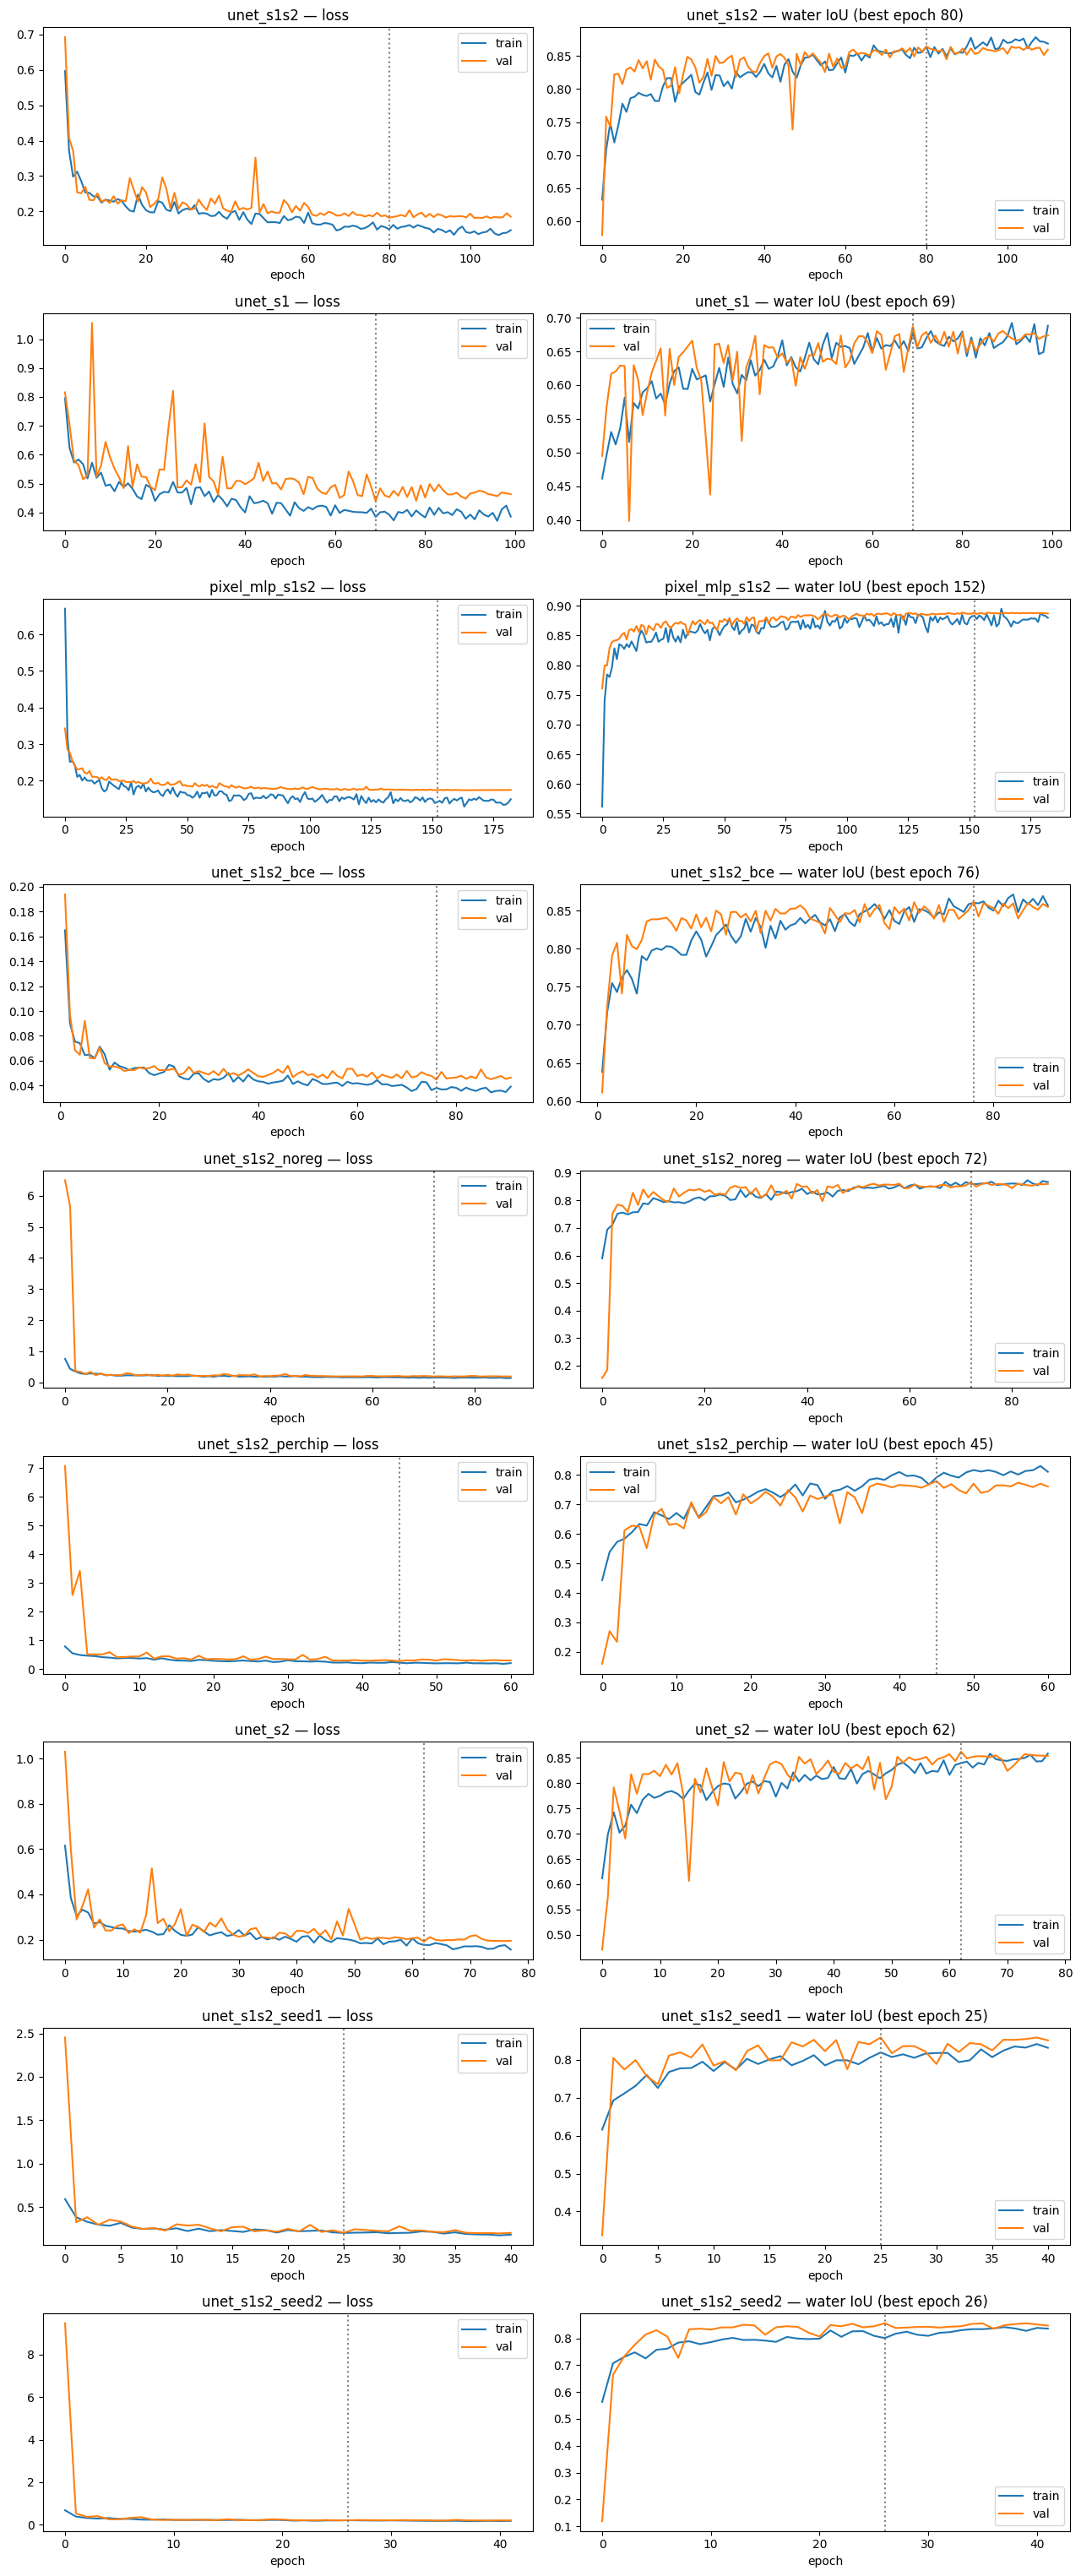

In [19]:
fig, axes = plt.subplots(len(MODELS), 2, figsize=(13, 3.4 * len(MODELS)), squeeze=False)
for row, name in zip(axes, MODELS):
    h = pd.read_csv(RUNS_DIR / name / "history.csv").drop_duplicates("epoch", keep="last")
    best = h.loc[h["val_water_iou"].idxmax(), "epoch"]
    row[0].plot(h["epoch"], h["loss"], label="train"); row[0].plot(h["epoch"], h["val_loss"], label="val")
    row[0].set_title(f"{name} — loss"); row[0].legend()
    row[1].plot(h["epoch"], h["water_iou"], label="train"); row[1].plot(h["epoch"], h["val_water_iou"], label="val")
    row[1].set_title(f"{name} — water IoU (best epoch {best})"); row[1].legend()
    for a in row:
        a.axvline(best, ls=":", c="gray"); a.set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 15. Final evaluation

1. Pick each model's decision threshold on the **validation** set.
2. Evaluate once on **test** (same events as training, different chips) and on **Bolivia** (an event never seen in training).

The proposal's **primary metric is water IoU on Bolivia**, so tables are sorted by that column. The proposal cites the original paper's Otsu baseline at about 0.32 IoU on Bolivia. Our own Otsu row should land near that value, which checks that the evaluation is set up the same way.

In [20]:
def predict_split(model, split, spec):
    ds = eval_dataset(split, spec["bands"], norm=spec["norm"]).map(lambda x, y: x)
    return model.predict(ds, verbose=0)[..., 0]


THRESHOLDS = {}
for name, model in MODELS.items():
    spec = EXPERIMENTS[name]
    Yv = np.asarray(load_cache("val")[1])
    pv = predict_split(model, "val", spec)
    grid = np.round(np.arange(0.2, 0.81, 0.05), 2)
    ious = [scores(confusion(Yv, pv >= t))["water_iou"] for t in grid]
    THRESHOLDS[name] = float(grid[int(np.argmax(ious))])
    for split in ("val", "test", "bolivia"):
        if split not in SPLITS:
            continue
        Y = np.asarray(load_cache(split)[1])
        p = pv if split == "val" else predict_split(model, split, spec)
        RESULTS.append({"method": name, "split": split, **scores(confusion(Y, p >= THRESHOLDS[name]))})
print("Thresholds chosen on validation:", THRESHOLDS)

results = pd.DataFrame(RESULTS).drop_duplicates(["method", "split"], keep="last")
results.to_csv(RUNS_DIR / "results.csv", index=False)
table = results.pivot(index="method", columns="split", values="water_iou")
table = table[[c for c in ("val", "test", "bolivia") if c in table]]
table = table.sort_values("bolivia" if "bolivia" in table else "test", ascending=False)
print("\nWater IoU by method and split (sorted by the primary metric):")
table.round(3)

Thresholds chosen on validation: {'unet_s1s2': 0.55, 'unet_s1': 0.6, 'pixel_mlp_s1s2': 0.65, 'unet_s1s2_bce': 0.55, 'unet_s1s2_noreg': 0.35, 'unet_s1s2_perchip': 0.4, 'unet_s2': 0.65, 'unet_s1s2_seed1': 0.5, 'unet_s1s2_seed2': 0.4}

Water IoU by method and split (sorted by the primary metric):


split,val,test,bolivia
method,,,
NDWI > 0 (S2),0.672,0.758,0.832
unet_s1s2,0.865,0.854,0.825
pixel_mlp_s1s2,0.889,0.868,0.814
unet_s1s2_seed1,0.859,0.853,0.811
unet_s2,0.864,0.847,0.808
unet_s1s2_noreg,0.868,0.850,0.803
unet_s1s2_seed2,0.858,0.855,0.800
unet_s1s2_bce,0.863,0.847,0.746
unet_s1s2_perchip,0.780,0.755,0.702


Full bolivia metrics:


,water_iou,f1,precision,recall,accuracy
method,,,,,
NDWI > 0 (S2),0.832,0.908,0.929,0.889,0.972
unet_s1s2,0.825,0.904,0.952,0.861,0.971
pixel_mlp_s1s2,0.814,0.897,0.968,0.836,0.970
unet_s1s2_seed1,0.811,0.896,0.951,0.846,0.969
unet_s2,0.808,0.894,0.943,0.850,0.968
unet_s1s2_noreg,0.803,0.891,0.958,0.832,0.968
unet_s1s2_seed2,0.800,0.889,0.966,0.823,0.967
unet_s1s2_bce,0.746,0.854,0.939,0.783,0.958
unet_s1s2_perchip,0.702,0.825,0.859,0.794,0.947


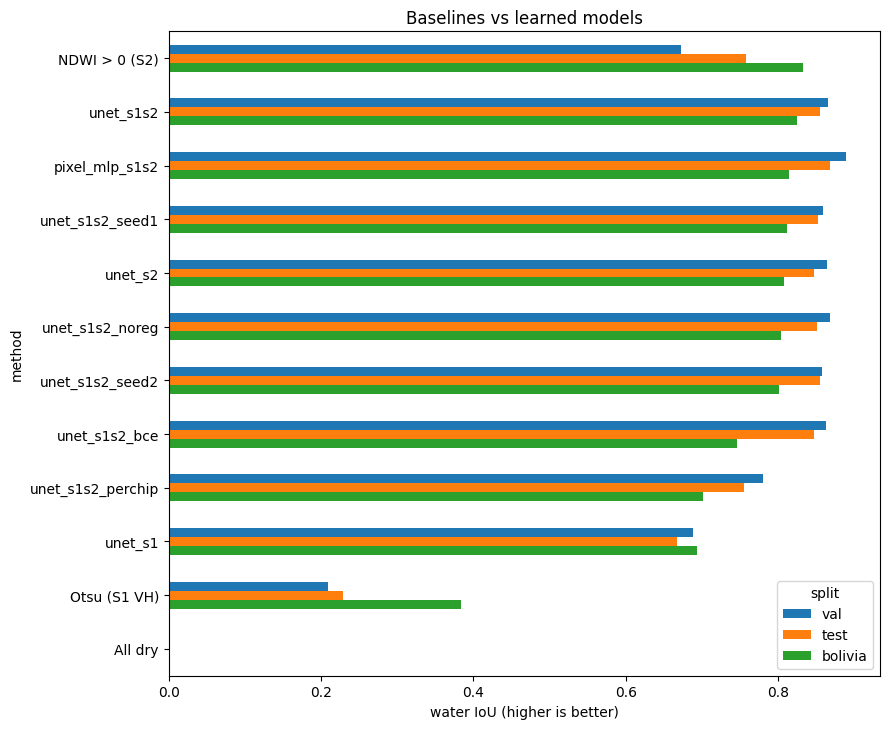


Reference U-Net across 3 seeds:


,mean,std,count
split,,,
bolivia,0.812,0.012,3
test,0.854,0.001,3
val,0.860,0.004,3


Differences between design choices smaller than about twice this std are within seed noise.


In [21]:
key_split = "bolivia" if "bolivia" in SPLITS else "test"
print(f"Full {key_split} metrics:")
display(results.query("split == @key_split").set_index("method").drop(columns="split")
        .sort_values("water_iou", ascending=False).round(3))

ax = table.plot.barh(figsize=(9, 0.45 * len(table) + 2))
ax.set_xlabel("water IoU (higher is better)"); ax.set_title("Baselines vs learned models"); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# Seed-to-seed variance of the reference model (proposal: report results across three random seeds).
seed_runs = [n for n in ("unet_s1s2", "unet_s1s2_seed1", "unet_s1s2_seed2") if n in MODELS]
if len(seed_runs) > 1:
    s = results[results["method"].isin(seed_runs)].groupby("split")["water_iou"].agg(["mean", "std", "count"])
    print(f"\nReference U-Net across {len(seed_runs)} seeds:")
    display(s.round(3))
    print("Differences between design choices smaller than about twice this std are within seed noise.")

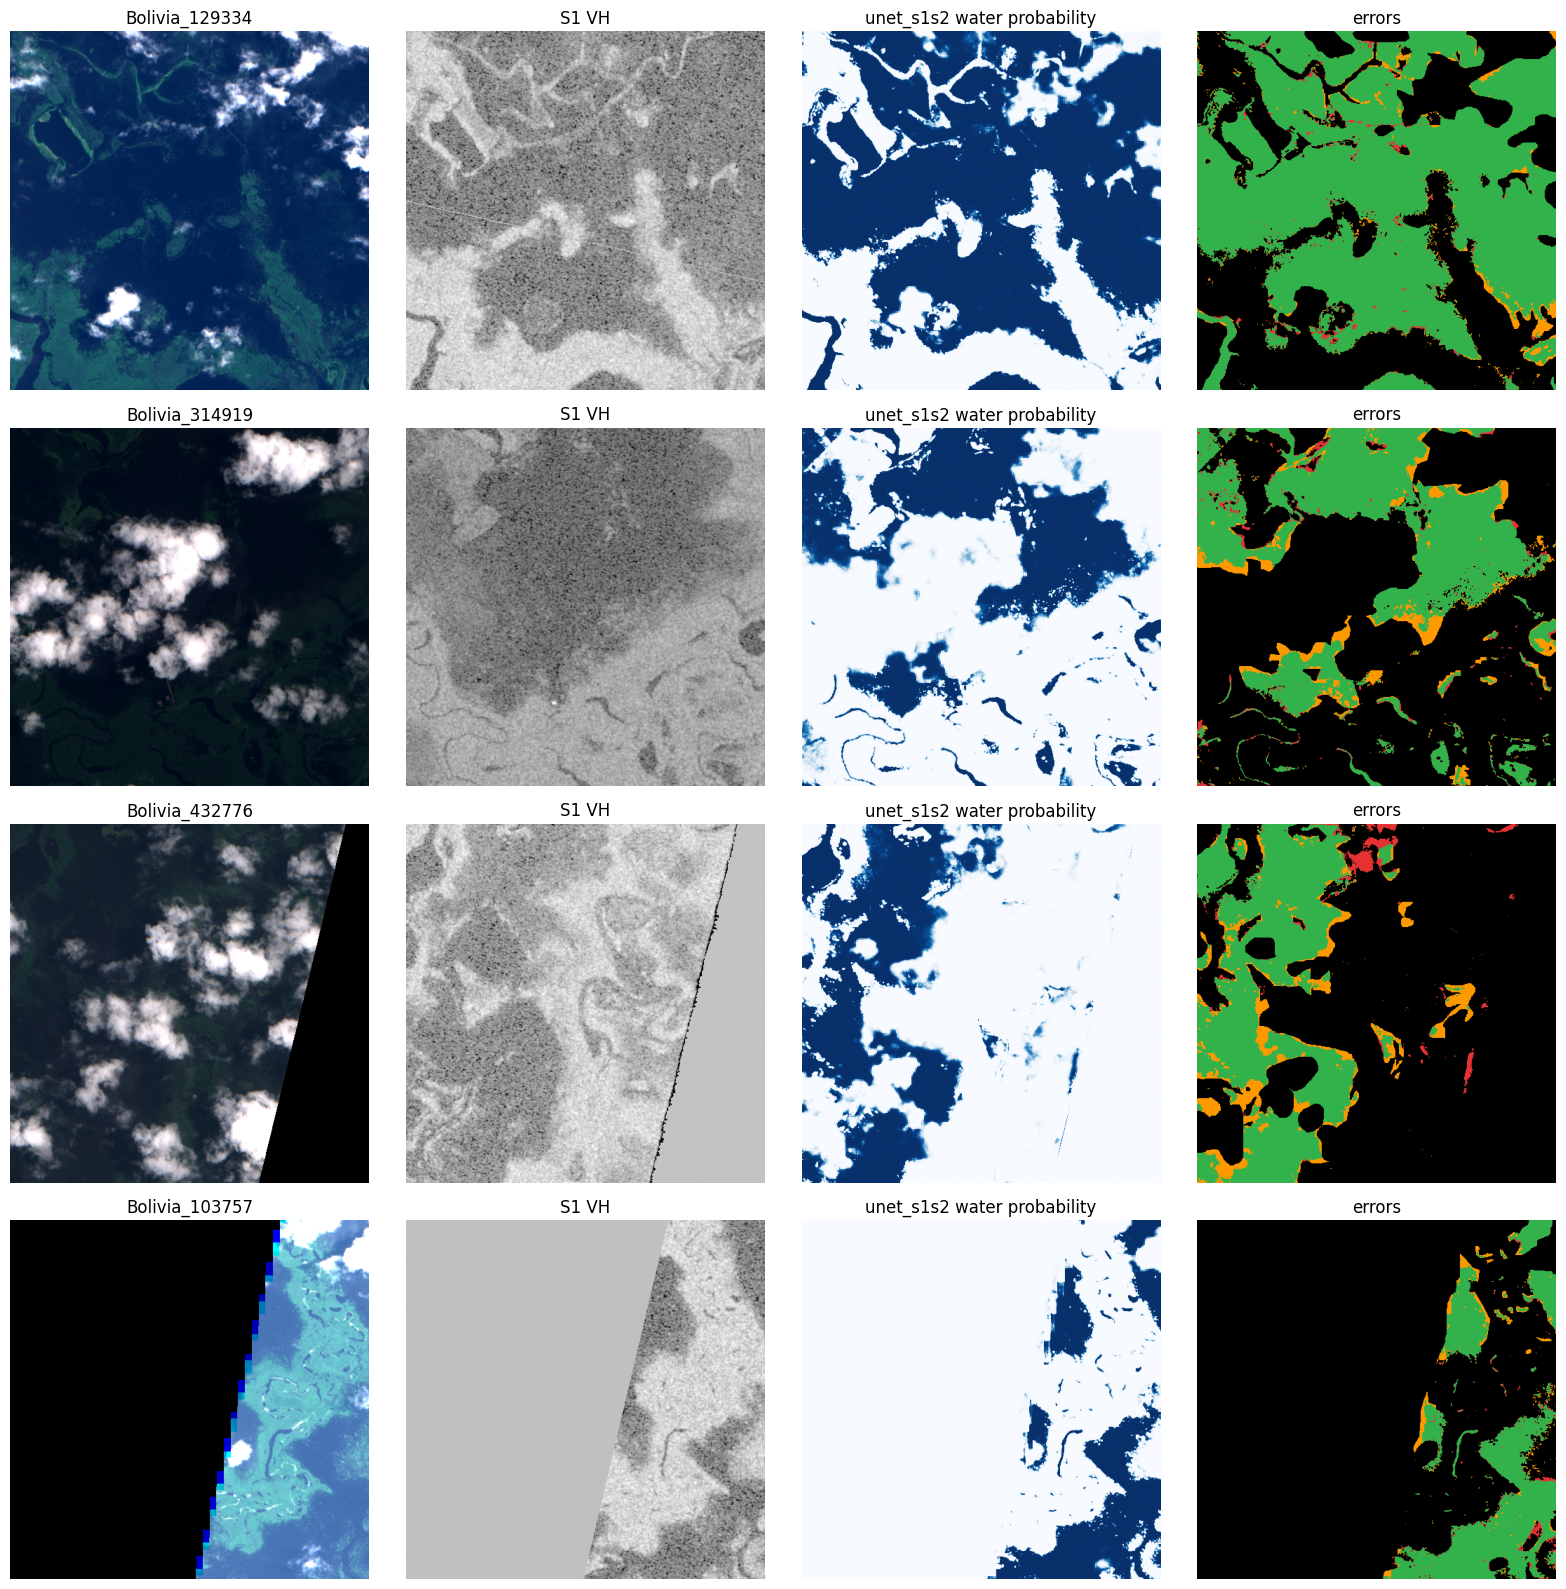

In [22]:
# Where does the best model go wrong? Green = correct water, red = false alarm, orange = missed water.
key_iou = results.query("split == @key_split").set_index("method")["water_iou"]
best_name = max(MODELS, key=lambda n: key_iou[n])
spec = EXPERIMENTS[best_name]
X, Y = load_cache(key_split)
probs = predict_split(MODELS[best_name], key_split, spec)
show = np.argsort([-(np.asarray(Y[i]) == 1).sum() for i in range(len(Y))])[:4]  # chips with the most water

fig, axes = plt.subplots(len(show), 4, figsize=(16, 4 * len(show)), squeeze=False)
for row, i in zip(axes, show):
    x = np.asarray(X[i], dtype=np.float32) * STD + MEAN
    y, pred = np.asarray(Y[i]), probs[i] >= THRESHOLDS[best_name]
    err = np.zeros(y.shape + (3,))
    err[(y == 1) & pred] = (0.2, 0.7, 0.3)
    err[(y == 0) & pred] = (0.9, 0.2, 0.2)
    err[(y == 1) & ~pred] = (1.0, 0.6, 0.0)
    row[0].imshow(rgb(x)); row[0].set_title(SPLITS[key_split][i])
    row[1].imshow(x[..., 1], cmap="gray"); row[1].set_title("S1 VH")
    row[2].imshow(probs[i], cmap="Blues", vmin=0, vmax=1); row[2].set_title(f"{best_name} water probability")
    row[3].imshow(err); row[3].set_title("errors")
    for a in row:
        a.axis("off")
plt.tight_layout(); plt.show()

## 16. Nepal case study (no labels — a generalisation test)

Sen1Floods11 contains no Nepal events, so this is an honest **"does it transfer?"** test, not a scored evaluation.
We use the **radar-only** model because monsoon floods happen under cloud, where optical images are blank.

**Get the images (Google Earth Engine, free for students):** export one Sentinel-1 scene from *before* and one from *after* the flood.
They come out in dB, the same units as Sen1Floods11. Save them to `nepal/nepal_s1_pre.tif` and `nepal/nepal_s1_post.tif` in the project folder on Drive.

```python
import ee
ee.Authenticate(); ee.Initialize(project="YOUR-GCP-PROJECT")
aoi = ee.Geometry.Rectangle([85.20, 27.80, 85.60, 28.20])  # example box — replace with your area of interest

def s1(start, end):
    col = (ee.ImageCollection("COPERNICUS/S1_GRD").filterBounds(aoi).filterDate(start, end)
           .filter(ee.Filter.eq("instrumentMode", "IW"))
           .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
           .select(["VV", "VH"]))
    return col.mosaic().clip(aoi)

for tag, (a, b) in {"pre": ("2026-06-01", "2026-06-30"), "post": ("2026-08-01", "2026-08-31")}.items():  # set real dates
    ee.batch.Export.image.toDrive(s1(a, b), description=f"nepal_s1_{tag}", folder="nepal-flood-segmentation",
                                  scale=10, region=aoi, fileFormat="GeoTIFF", maxPixels=1e10).start()
```

Expect false alarms in steep terrain: mountain slopes facing away from the satellite fall in **radar shadow**, which looks as dark as water.
Subtracting the pre-flood water (permanent rivers) from the post-flood map gives the **newly flooded** area.

Newly flooded area: 34.94 km²


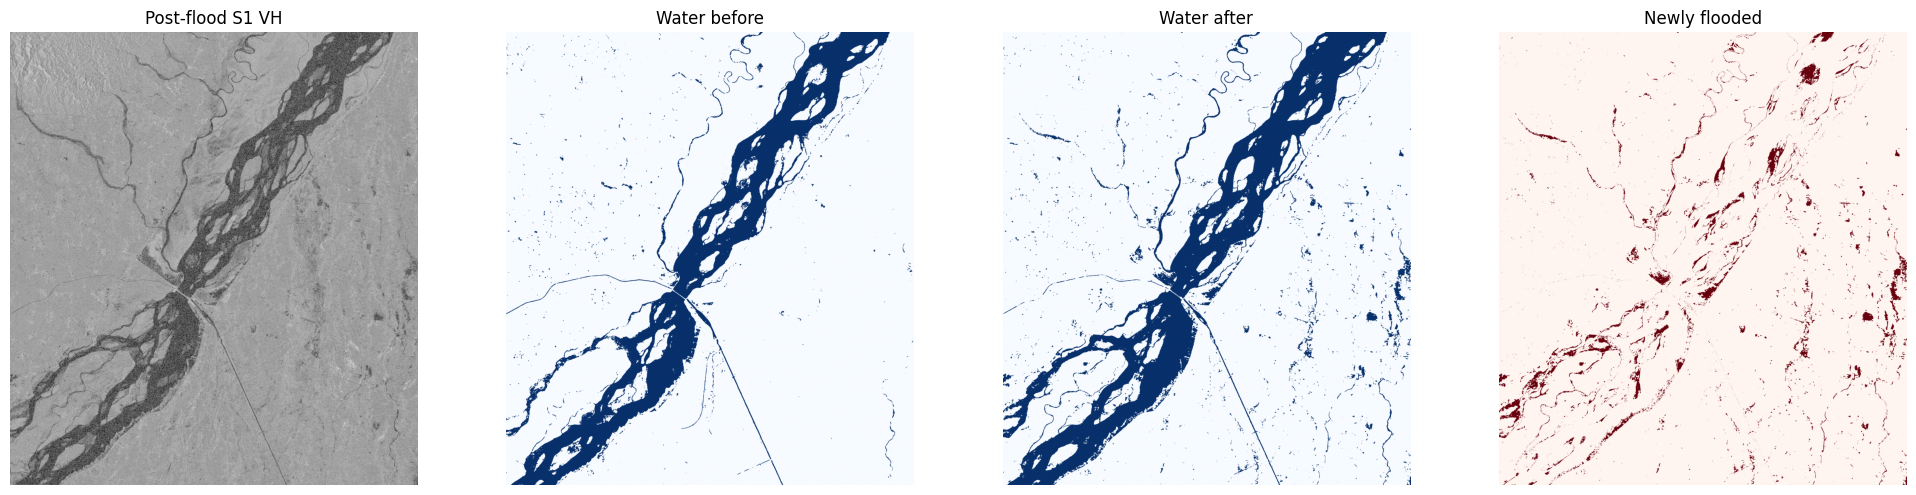

In [23]:
def make_synthetic_scene(path, h=700, w=900, flooded=False, seed=1):
    from scipy.ndimage import gaussian_filter
    rng = np.random.default_rng(seed)
    river = np.abs(np.arange(w)[None, :] - (w / 2 + 60 * np.sin(np.arange(h)[:, None] / 60))) < (60 if flooded else 15)
    vv = -8 + rng.normal(0, 2, (h, w)) - 12 * river
    vh = -15 + rng.normal(0, 2, (h, w)) - 9 * river
    with rasterio.open(path, "w", driver="GTiff", width=w, height=h, count=2, dtype="float32", crs="EPSG:32645",
                       transform=from_origin(330000, 3120000, 10, 10)) as dst:
        dst.write(np.stack([vv, vh]).astype("float32"))


def load_s1_scene(path):
    with rasterio.open(path) as src:
        arr = src.read([1, 2]).astype("float32")
        transform, crs = src.transform, src.crs
    if np.nanmedian(arr) > 0:  # linear backscatter → dB
        arr = 10 * np.log10(np.clip(arr, 1e-6, None))
    x = np.clip(arr.transpose(1, 2, 0), -50, 5)
    return normalise(x, bands=slice(0, 2)), transform, crs


def tile_starts(n, tile, step):
    if n <= tile:
        return [0]
    s = list(range(0, n - tile + 1, step))
    return s if s[-1] == n - tile else s + [n - tile]


def predict_scene(model, x, tile=512, overlap=64, batch=16):
    # Sliding-window prediction with overlapping tiles averaged, so tile borders don't show.
    H, W, _ = x.shape
    xp = np.pad(x, ((0, max(0, tile - H)), (0, max(0, tile - W)), (0, 0)))
    Hp, Wp = xp.shape[:2]
    prob, cnt = np.zeros((Hp, Wp), np.float32), np.zeros((Hp, Wp), np.float32)
    coords = [(r, c) for r in tile_starts(Hp, tile, tile - overlap) for c in tile_starts(Wp, tile, tile - overlap)]
    for k in range(0, len(coords), batch):
        chunk = coords[k:k + batch]
        p = model.predict(np.stack([xp[r:r + tile, c:c + tile] for r, c in chunk]), verbose=0)[..., 0]
        for (r, c), pi in zip(chunk, p):
            prob[r:r + tile, c:c + tile] += pi
            cnt[r:r + tile, c:c + tile] += 1
    return (prob / np.maximum(cnt, 1))[:H, :W]


def pixel_area_m2(transform, crs, H):
    if crs is not None and crs.is_projected:
        return abs(transform.a * transform.e)
    lat = transform.f + transform.e * H / 2
    return abs(transform.a) * 111320 * math.cos(math.radians(lat)) * abs(transform.e) * 110574


pre_path, post_path = NEPAL_DIR / "nepal_s1_pre.tif", NEPAL_DIR / "nepal_s1_post.tif"
if SMOKE_TEST:
    make_synthetic_scene(pre_path, flooded=False); make_synthetic_scene(post_path, flooded=True)

if "unet_s1" not in MODELS:
    print("Train the 'unet_s1' experiment first (Section 12).")
elif not post_path.exists():
    print(f"No Nepal scene yet — export it with the Earth Engine snippet above and save it as {post_path}")
else:
    model, thr = MODELS["unet_s1"], THRESHOLDS["unet_s1"]
    x_post, transform, crs = load_s1_scene(post_path)
    water_post = predict_scene(model, x_post) >= thr
    if pre_path.exists():
        x_pre, _, _ = load_s1_scene(pre_path)
        water_pre = predict_scene(model, x_pre) >= thr
        hh, ww = min(water_pre.shape[0], water_post.shape[0]), min(water_pre.shape[1], water_post.shape[1])
        new_water = water_post[:hh, :ww] & ~water_pre[:hh, :ww]
    else:
        water_pre, new_water = None, water_post
    km2 = new_water.sum() * pixel_area_m2(transform, crs, water_post.shape[0]) / 1e6
    print(f"Newly flooded area: {km2:.2f} km²" + ("" if water_pre is not None else " (no pre-flood image: includes permanent rivers)"))

    panels = [("Post-flood S1 VH", x_post[..., 1], "gray"), ("Water after", water_post, "Blues")]
    if water_pre is not None:
        panels.insert(1, ("Water before", water_pre, "Blues"))
    panels.append(("Newly flooded", new_water, "Reds"))
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 5))
    for a, (title, img, cmap) in zip(axes, panels):
        a.imshow(img, cmap=cmap); a.set_title(title); a.axis("off")
    plt.tight_layout(); plt.show()